# E-commerce Furniture Dataset **2024**

## Problem Statement

The project aims to analyze an e-commerce furniture dataset to understand price distribution and product sales patterns.  
It attempts to build machine learning models to predict the number of units sold based on features like price and shipping type.  
However, due to limited feature availability, achieving high prediction accuracy remains a challenge.

## Tools Used

- **Python** – Programming language used for data analysis and modeling  
- **Pandas** – Data cleaning and manipulation  
- **NumPy** – Numerical computations  
- **Matplotlib & Seaborn** – Data visualization  
- **Scikit-learn** – Machine learning models and preprocessing  
- **XGBoost** – Advanced regression model for improved performance  
- **Jupyter Notebook / Google Colab** – Development environment

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


## Load Dataset

The dataset contains furniture product details such as price, units sold, and shipping type.  
It is used to analyze sales patterns and understand the relationship between price and product performance.

In [90]:
df = pd.read_csv("/content/ecommerce_furniture_dataset_2024.csv")



## **Dataset Overview**

In this step, we examine the structure of the dataset including data types, number of columns, and missing values.

In [91]:
print(df.head())
print(df.shape)


                                        productTitle originalPrice    price  \
0  Dresser For Bedroom With 9 Fabric Drawers Ward...           NaN   $46.79   
1  Outdoor Conversation Set 4 Pieces Patio Furnit...           NaN  $169.72   
2  Desser For Bedroom With 7 Fabric Drawers Organ...         $78.4   $39.46   
3  Modern Accent Boucle Chair,Upholstered Tufted ...           NaN  $111.99   
4  Small Unit Simple Computer Desk Household Wood...        $48.82   $21.37   

   sold        tagText  
0   600  Free shipping  
1     0  Free shipping  
2     7  Free shipping  
3     0  Free shipping  
4     1  Free shipping  
(2000, 5)


In [68]:
print(df.isnull().sum())


productTitle        0
originalPrice    1513
price               0
sold                0
tagText             3
dtype: int64


In [69]:
df.drop(['originalPrice'], axis=1, inplace=True)


In [70]:
df.columns

Index(['productTitle', 'price', 'sold', 'tagText'], dtype='object')

In [71]:
df['price'] = (
    df['price']
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)


In [72]:
df['tagText'] = df['tagText'].apply(
    lambda x: x if x in ['Free shipping', '+Shipping: $5.09'] else 'others'
)

print(df['tagText'].value_counts())


tagText
Free shipping       1880
others               111
+Shipping: $5.09       9
Name: count, dtype: int64


In [73]:
le = LabelEncoder()
df['tagText'] = le.fit_transform(df['tagText'])


## Dataset Overview & Preprocessing

In this step, the dataset is loaded and its structure is examined using functions like `head()`, `shape`, and `isnull()` to understand the data and identify missing values.  

The column `originalPrice` is dropped due to a high number of missing values, making it less useful for analysis.  

The `price` column is cleaned by removing currency symbols and converting it into a numeric format for further processing.  

The `tagText` column is simplified into key categories such as "Free shipping", "+Shipping: $5.09", and "others" to reduce noise in the data.  

Finally, the categorical `tagText` values are converted into numerical form using Label Encoding to prepare the dataset for machine learning models.

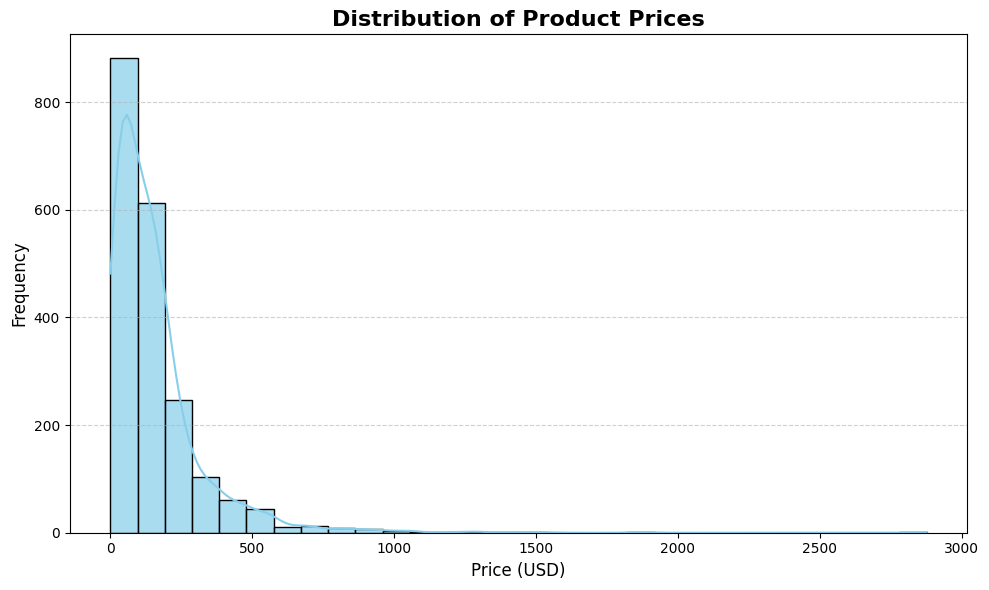

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    df['price'],
    kde=True,
    bins=30,
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

plt.title("Distribution of Product Prices", fontsize=16, fontweight='bold')
plt.xlabel("Price (USD)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Price Distribution of Furniture Products

### What this chart shows

This chart displays the distribution of furniture product prices in the dataset, showing how prices are spread across different ranges.

### Key observations

- Most products are concentrated in lower to mid price ranges  
- A few products have significantly higher prices (outliers)  
- The distribution is slightly right-skewed, indicating fewer high-priced items  

### Business insight

The majority of furniture items are priced affordably, suggesting a focus on budget-friendly products. Higher-priced items exist but are less common, possibly targeting niche or premium customers.

### Actionable recommendation

- Focus marketing efforts on popular price ranges to maximize sales  
- Introduce competitive pricing strategies in mid-range segments  
- Analyze high-priced items separately to improve premium sales  

### Key takeaway

Most furniture products fall within affordable price ranges, with fewer premium items, indicating a price-sensitive market with opportunities in both budget and high-end segments.

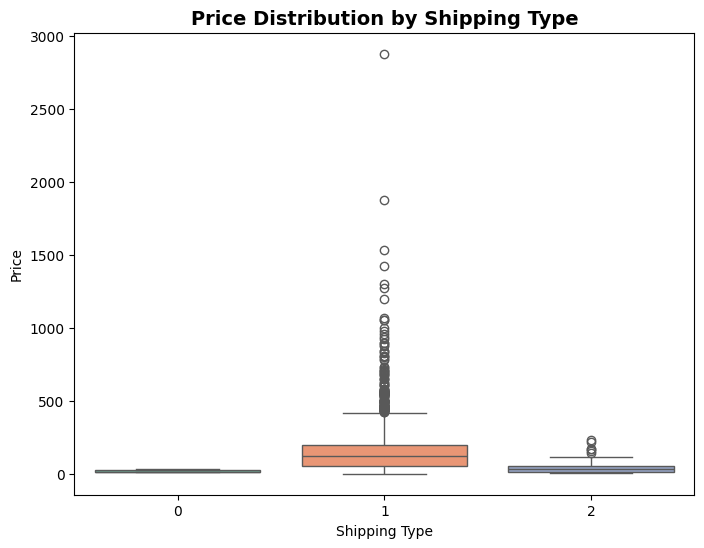

In [75]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='tagText',
    y='price',
    data=df,
    hue='tagText',
    palette='Set2',
    legend=False
)

plt.title("Price Distribution by Shipping Type", fontsize=14, weight='bold')
plt.xlabel("Shipping Type")
plt.ylabel("Price")

plt.show()

## Price Distribution by Shipping Type

### What this chart shows

This chart compares the distribution of product prices across different shipping types (tags) in the dataset.

### Key observations

- Most products fall within a similar price range across all shipping types  
- Some categories show wider price variation with noticeable outliers  
- Free shipping products dominate the dataset and show a broad spread of prices  

### Business insight

Shipping type does not significantly change the overall price range, but products with free shipping appear more frequently and span across both low and high price segments.

### Actionable recommendation

- Continue offering free shipping as it covers a wide range of products  
- Analyze high-priced outliers to identify premium product opportunities  
- Optimize pricing strategies based on shipping categories  

### Key takeaway

Free shipping products dominate the dataset and cover a wide price range, while shipping type has limited impact on overall price distribution.

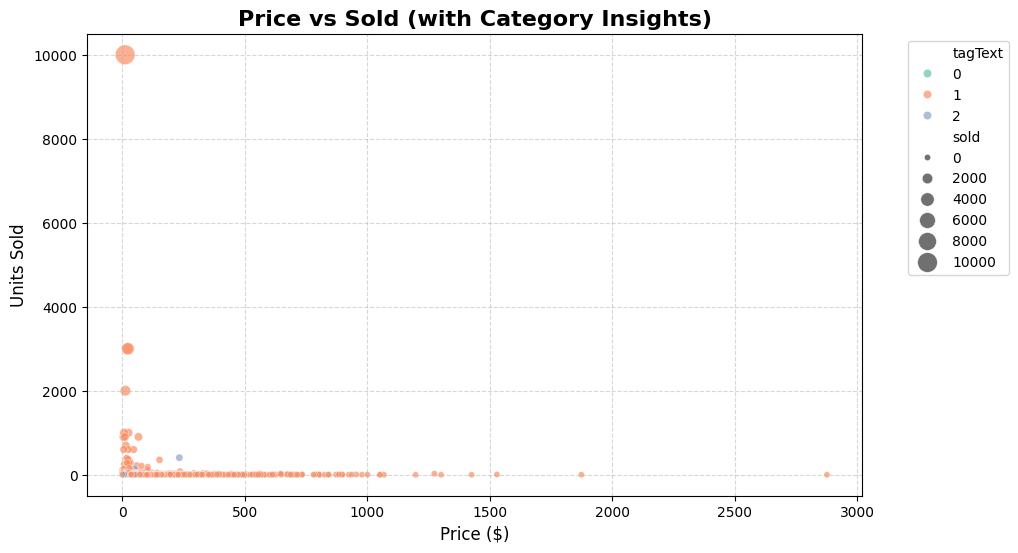

In [76]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='price',
    y='sold',
    data=df,
    hue='tagText',          # adds category insight
    palette='Set2',
    size='sold',            # bubble size
    sizes=(20, 200),
    alpha=0.7
)

plt.title("Price vs Sold (with Category Insights)", fontsize=16, weight='bold')
plt.xlabel("Price ($)", fontsize=12)
plt.ylabel("Units Sold", fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## Price vs Units Sold Analysis

### What this chart shows

This chart illustrates the relationship between product price and the number of units sold, with additional insights based on shipping type.

### Key observations

- Lower-priced products tend to have higher sales compared to expensive items  
- High-priced products generally show lower sales volume  
- Free shipping products are more densely distributed and appear across all price ranges  

### Business insight

There is an inverse relationship between price and sales, indicating that customers are more likely to purchase affordable items. Shipping type, especially free shipping, plays a role in attracting buyers across different price segments.

### Actionable recommendation

- Focus on competitive pricing to increase sales volume  
- Offer free shipping to improve product attractiveness  
- Optimize pricing strategies for high-priced items to boost demand  

### Key takeaway

Lower-priced products drive higher sales, and free shipping enhances product appeal across different price ranges.

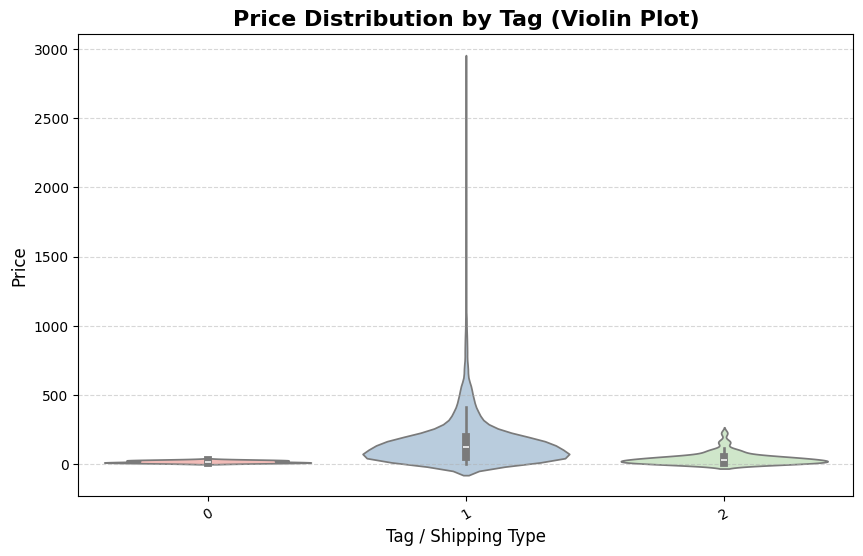

In [77]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='tagText',
    y='price',
    data=df,
    hue='tagText',
    palette='Pastel1',
    legend=False
)

plt.title("Price Distribution by Tag (Violin Plot)", fontsize=16, weight='bold')
plt.xlabel("Tag / Shipping Type", fontsize=12)
plt.ylabel("Price", fontsize=12)

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Price Distribution by Shipping Type (Violin Plot)

### What this chart shows

This chart visualizes the distribution and density of product prices across different shipping types using a violin plot.

### Key observations

- Most products are concentrated in lower to mid price ranges across all categories  
- Free shipping category shows a wider spread and higher density of products  
- Some categories have fewer products, resulting in narrower distributions  

### Business insight

The violin plot reveals not only the range of prices but also where most products are concentrated. Free shipping products dominate the dataset and cover a broader range of prices, indicating higher availability and variety.

### Actionable recommendation

- Focus on price segments with high density to maximize sales  
- Expand product variety in less represented shipping categories  
- Use free shipping strategically to cover multiple price segments  

### Key takeaway

Free shipping products dominate both in quantity and price range, while other categories have limited distribution, highlighting opportunities for diversification.

In [78]:
# Encode categorical column
le = LabelEncoder()
df['tagText'] = le.fit_transform(df['tagText'])


In [79]:
X = df[['price', 'tagText']]   # using both features
y = df['sold']                 # target



In [80]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [82]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestRegressor(max_depth=15, min_samples_split=5, n_estimators=300,
                      random_state=42)

In [83]:
y_pred = model.predict(X_test)

In [84]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Improved Model Performance:")
print("MSE:", mse)
print("R2 Score:", r2)

Improved Model Performance:
MSE: 10872.171278704807
R2 Score: -0.9826996730151387


In [85]:
# Example input (change based on dataset values)
sample = pd.DataFrame({
    'price': [150],
    'tagText': ['Free Shipping']
})


In [86]:
sample = pd.DataFrame({
    'price': [150],
    'tagText': [0]   # directly encoded value
})

sample_scaled = scaler.transform(sample)
prediction = model.predict(sample_scaled)

print("Predicted Units Sold:", prediction[0])

Predicted Units Sold: 2.5785809222998815


## Machine Learning Model for Sales Prediction

### What this code does

This section builds a machine learning model to predict the number of units sold using features such as product price and shipping type.  
The categorical feature `tagText` is encoded using Label Encoding, and feature scaling is applied using StandardScaler.  
The data is split into training and testing sets, and a Random Forest Regressor is trained to make predictions.

### Key observations

- The model produced a negative R² score (-0.98), indicating poor performance  
- Predictions are generated successfully but are not reliable  
- The model fails to capture meaningful relationships between features and target  

### Business insight

The poor performance is not due to incorrect implementation but due to limited and weak features in the dataset.  
Important factors such as product ratings, reviews, category, and time-related data are missing, which are crucial for predicting sales accurately.

### Reason for low accuracy

- The dataset contains only basic features (price and shipping type)  
- There is no strong relationship between these features and units sold  
- Lack of additional informative features limits the model’s learning capability  

### Actionable recommendation

- Include more relevant features such as ratings, reviews, product category, and date/time  
- Perform feature engineering to extract meaningful patterns  
- Use richer datasets for better predictive performance  

### Key takeaway

The model implementation is correct, but the dataset is limited (weak), making accurate prediction of product sales difficult.

In [89]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

#Load Dataset

df = pd.read_csv("ecommerce_furniture_dataset_2024.csv")


#  Data Cleaning

df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)
df.dropna(inplace=True)

#  Feature Engineering

le = LabelEncoder()
df['tagText'] = le.fit_transform(df['tagText'])


#  Features & Target

X = df[['price', 'tagText']]
y = df['sold']


#  Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#  Train XGBoost Model

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

#
#  Prediction

y_pred = model.predict(X_test)


#  Evaluation

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("XGBoost Model Performance:")
print("MSE:", mse)
print("R2 Score:", r2)


# Sample Prediction

sample = pd.DataFrame({
    'price': [150],
    'tagText': [0]   # encoded value
})

prediction = model.predict(sample)

print("\nPredicted Units Sold:", prediction[0])

XGBoost Model Performance:
MSE: 474988.3125
R2 Score: -2.451323986053467

Predicted Units Sold: 12.253863


## Advanced Model: XGBoost for Sales Prediction

### What this code does

In this step, an advanced machine learning model (XGBoost Regressor) is used to improve the prediction of units sold.  
The dataset is first cleaned by converting price into numeric format and removing missing values.  
Categorical data (`tagText`) is encoded, and the dataset is split into training and testing sets before training the XGBoost model.

### Key observations

- The model produced a very low R² score (-2.45), indicating extremely poor performance  
- The Mean Squared Error (MSE) is high, showing large prediction errors  
- Although predictions are generated successfully, they are not reliable  

### Analysis

Even after using a more powerful model like XGBoost, the performance did not improve and became worse than previous models.  
This confirms that the issue is not with the model but with the dataset itself.

### Reason for poor performance

- The dataset contains only limited features such as price and shipping type  
- There is no strong relationship between these features and the number of units sold  
- Important factors like ratings, reviews, product category, brand, and user behavior are missing  

### Key takeaway

Using advanced models does not guarantee better performance when the dataset lacks meaningful features.  
The quality and relevance of data play a more important role than model complexity.

---

## Project Conclusion

This project focused on analyzing an e-commerce furniture dataset to understand price distribution and sales patterns.  
Various data visualization techniques were used to gain insights into product pricing, shipping types, and their relationship with sales.

Machine learning models including Linear Regression, Random Forest, and XGBoost were implemented to predict the number of units sold.  
However, all models showed poor performance due to the limited number of features available in the dataset.

The results demonstrate that accurate prediction depends heavily on the quality and richness of the dataset rather than the choice of model.  
Additional features such as product ratings, reviews, category, and customer behavior would be required to build a reliable predictive system.

### Final takeaway

While the implementation of data analysis and machine learning was successful, the dataset was not sufficiently informative for accurate sales prediction, highlighting the importance of feature-rich data in real-world machine learning applications.